In [1]:
import pickle
import pandas as pd

In [2]:
with open("novelpy/challenge_scores.pickle", "rb") as f:
    results = pickle.load(f)

In [3]:
df_results = pd.DataFrame(results).T
df_results["PaperProjectID"] = df_results.index
df_results = df_results[df_results["score"].isna()]

In [4]:
df_results

,paper_ref,ref_ref,ref_spread,n_related,titles_only,status,score,PaperProjectID
0,0.095073,0.11019,0.043794,21,False,OK,NaN,0
1,0.091445,0.113558,0.039213,23,False,OK,NaN,1
2,0.115772,0.128629,0.040092,37,False,OK,NaN,2
3,0.11318,0.128483,0.045708,18,False,OK,NaN,3
4,0.122864,0.118315,0.029176,42,False,OK,NaN,4
...,...,...,...,...,...,...,...,...
5956,0.12039,0.126892,0.038307,38,False,OK,NaN,5956
5957,0.074836,0.077646,0.028048,14,False,OK,NaN,5957
5958,0.094772,0.115242,0.034841,58,False,OK,NaN,5958
5959,0.125931,0.144175,0.041903,27,False,OK,NaN,5959


In [5]:
df_with_ids = pd.read_csv("novelpy/novelpy.csv")
df_with_ids = df_results.merge(df_with_ids, on="PaperProjectID", how="left")
df_with_ids = df_with_ids[["PaperProjectID", "paper_ref", "ref_ref", "ref_spread", "PMID"]]
df_with_ids

,PaperProjectID,paper_ref,ref_ref,ref_spread,PMID
0,0,0.095073,0.11019,0.043794,10623571
1,1,0.091445,0.113558,0.039213,10626936
2,2,0.115772,0.128629,0.040092,10626943
3,3,0.11318,0.128483,0.045708,10630314
4,4,0.122864,0.118315,0.029176,10631045
...,...,...,...,...,...
5505,5956,0.12039,0.126892,0.038307,11116287
5506,5957,0.074836,0.077646,0.028048,11125042
5507,5958,0.094772,0.115242,0.034841,11133219
5508,5959,0.125931,0.144175,0.041903,11134555


In [6]:
target_scores = [
    "c04_foster",
    "c04_lee",
    "c04_uzzi",
    "c04_wang",
    "mesh_foster",
    "mesh_lee",
    "mesh_uzzi",
    "mesh_wang",
    "di_values_10years"
]
df_scores = (
    pd.read_csv("novelpy/novelpy_data_di_values_10years_result.csv")
    .rename(columns={"novelty_score": "di_values_10years"})
)
print(df_scores.columns)
for score in target_scores[:-1]:
    df = pd.read_feather(f"novelpy/novelpy_data_{score}_result.feather")
    #df_scores[score] = df["score"]
    #print(df["score"])
    print(score, df.columns)
    df_scores = df_scores.merge(df[["PMID", "score"]], on="PMID", how="left").rename(columns={"score": score})

Index(['Unnamed: 0', 'PMID', 'di_values_10years'], dtype='str')
c04_foster Index(['PMID', 'score'], dtype='str')
c04_lee Index(['PMID', 'score'], dtype='str')
c04_uzzi Index(['PMID', 'score'], dtype='str')
c04_wang Index(['PMID', 'score'], dtype='str')
mesh_foster Index(['PMID', 'score'], dtype='str')
mesh_lee Index(['PMID', 'score'], dtype='str')
mesh_uzzi Index(['PMID', 'score'], dtype='str')
mesh_wang Index(['PMID', 'score'], dtype='str')


In [7]:
df_scores

,Unnamed: 0,PMID,di_values_10years,c04_foster,c04_lee,c04_uzzi,c04_wang,mesh_foster,mesh_lee,mesh_uzzi,mesh_wang
0,0,10623571,0.000808,0.500000,0.738023,-0.485389,0.0,0.500000,0.738023,-0.485389,0.000000
1,0,10623571,0.000808,0.500000,0.738023,-0.485389,0.0,0.500000,0.738023,-0.485389,1.386156
2,0,10623571,0.000808,0.500000,0.738023,-0.485389,0.0,0.500000,0.738023,NaN,0.000000
3,0,10623571,0.000808,0.500000,0.738023,-0.485389,0.0,0.500000,0.738023,NaN,1.386156
4,0,10623571,0.000808,0.500000,0.738023,-0.485389,0.0,0.500000,0.692468,-0.485389,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
1216507,76181,20100198,-0.004944,0.666667,-1.486635,NaN,0.0,0.692308,-1.486635,NaN,1.119472
1216508,76181,20100198,-0.004944,0.666667,-1.486635,NaN,0.0,0.692308,1.570750,NaN,0.000000
1216509,76181,20100198,-0.004944,0.666667,-1.486635,NaN,0.0,0.692308,1.570750,NaN,1.119472
1216510,76181,20100198,-0.004944,0.666667,-1.486635,NaN,0.0,0.692308,1.570750,NaN,0.000000


In [8]:
our_scores = [
    "paper_ref",
    "ref_ref",
    "ref_spread"
]
df_results = df_with_ids[our_scores + ["PMID"]]

In [9]:
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())  

df_results["score_mean"] = (normalize(df_results["ref_ref"]) + normalize(df_results["paper_ref"])) / 2
df_results["score_product"] = (normalize(df_results["ref_ref"]) * normalize(df_results["paper_ref"])).apply(
    lambda x: x**(0.5) if x > 0 else 0
)
df_results["score_harmonic"] = 2 * (normalize(df_results["ref_ref"]) * normalize(df_results["paper_ref"])) / (0.000000001 + normalize(df_results["ref_ref"]) + normalize(df_results["paper_ref"]))    
df_results["score_max"] = normalize(df_results["ref_ref"]).combine(normalize(df_results["paper_ref"]), max)     
df_results["score_min"] = normalize(df_results["ref_ref"]).combine(normalize(df_results["paper_ref"]), min) 

In [10]:
our_scores += [
    "score_mean",
    "score_product",
    "score_harmonic",
    "score_max",
    "score_min"]

In [11]:
df_all = df_results.merge(df_scores, on="PMID", how="left")

In [16]:
df_all[our_scores + target_scores].corr(method="spearman").loc[target_scores, our_scores].map(lambda x: f"{x:.2f}" if x > 0.1 else "")

,paper_ref,ref_ref,ref_spread,score_mean,score_product,score_harmonic,score_max,score_min
c04_foster,0.10,0.18,,0.15,0.14,0.13,0.18,0.11
c04_lee,,0.10,,,,,,
c04_uzzi,,,,,,,,
c04_wang,,,,,,,,
mesh_foster,0.10,0.19,,0.16,0.15,0.14,0.19,0.11
mesh_lee,,,,,,,,
mesh_uzzi,,,0.12,,,,,
mesh_wang,,,,,,,,
di_values_10years,0.22,0.16,0.18,0.21,0.21,0.21,0.17,0.21


In [63]:
sel = df_all[our_scores + target_scores]

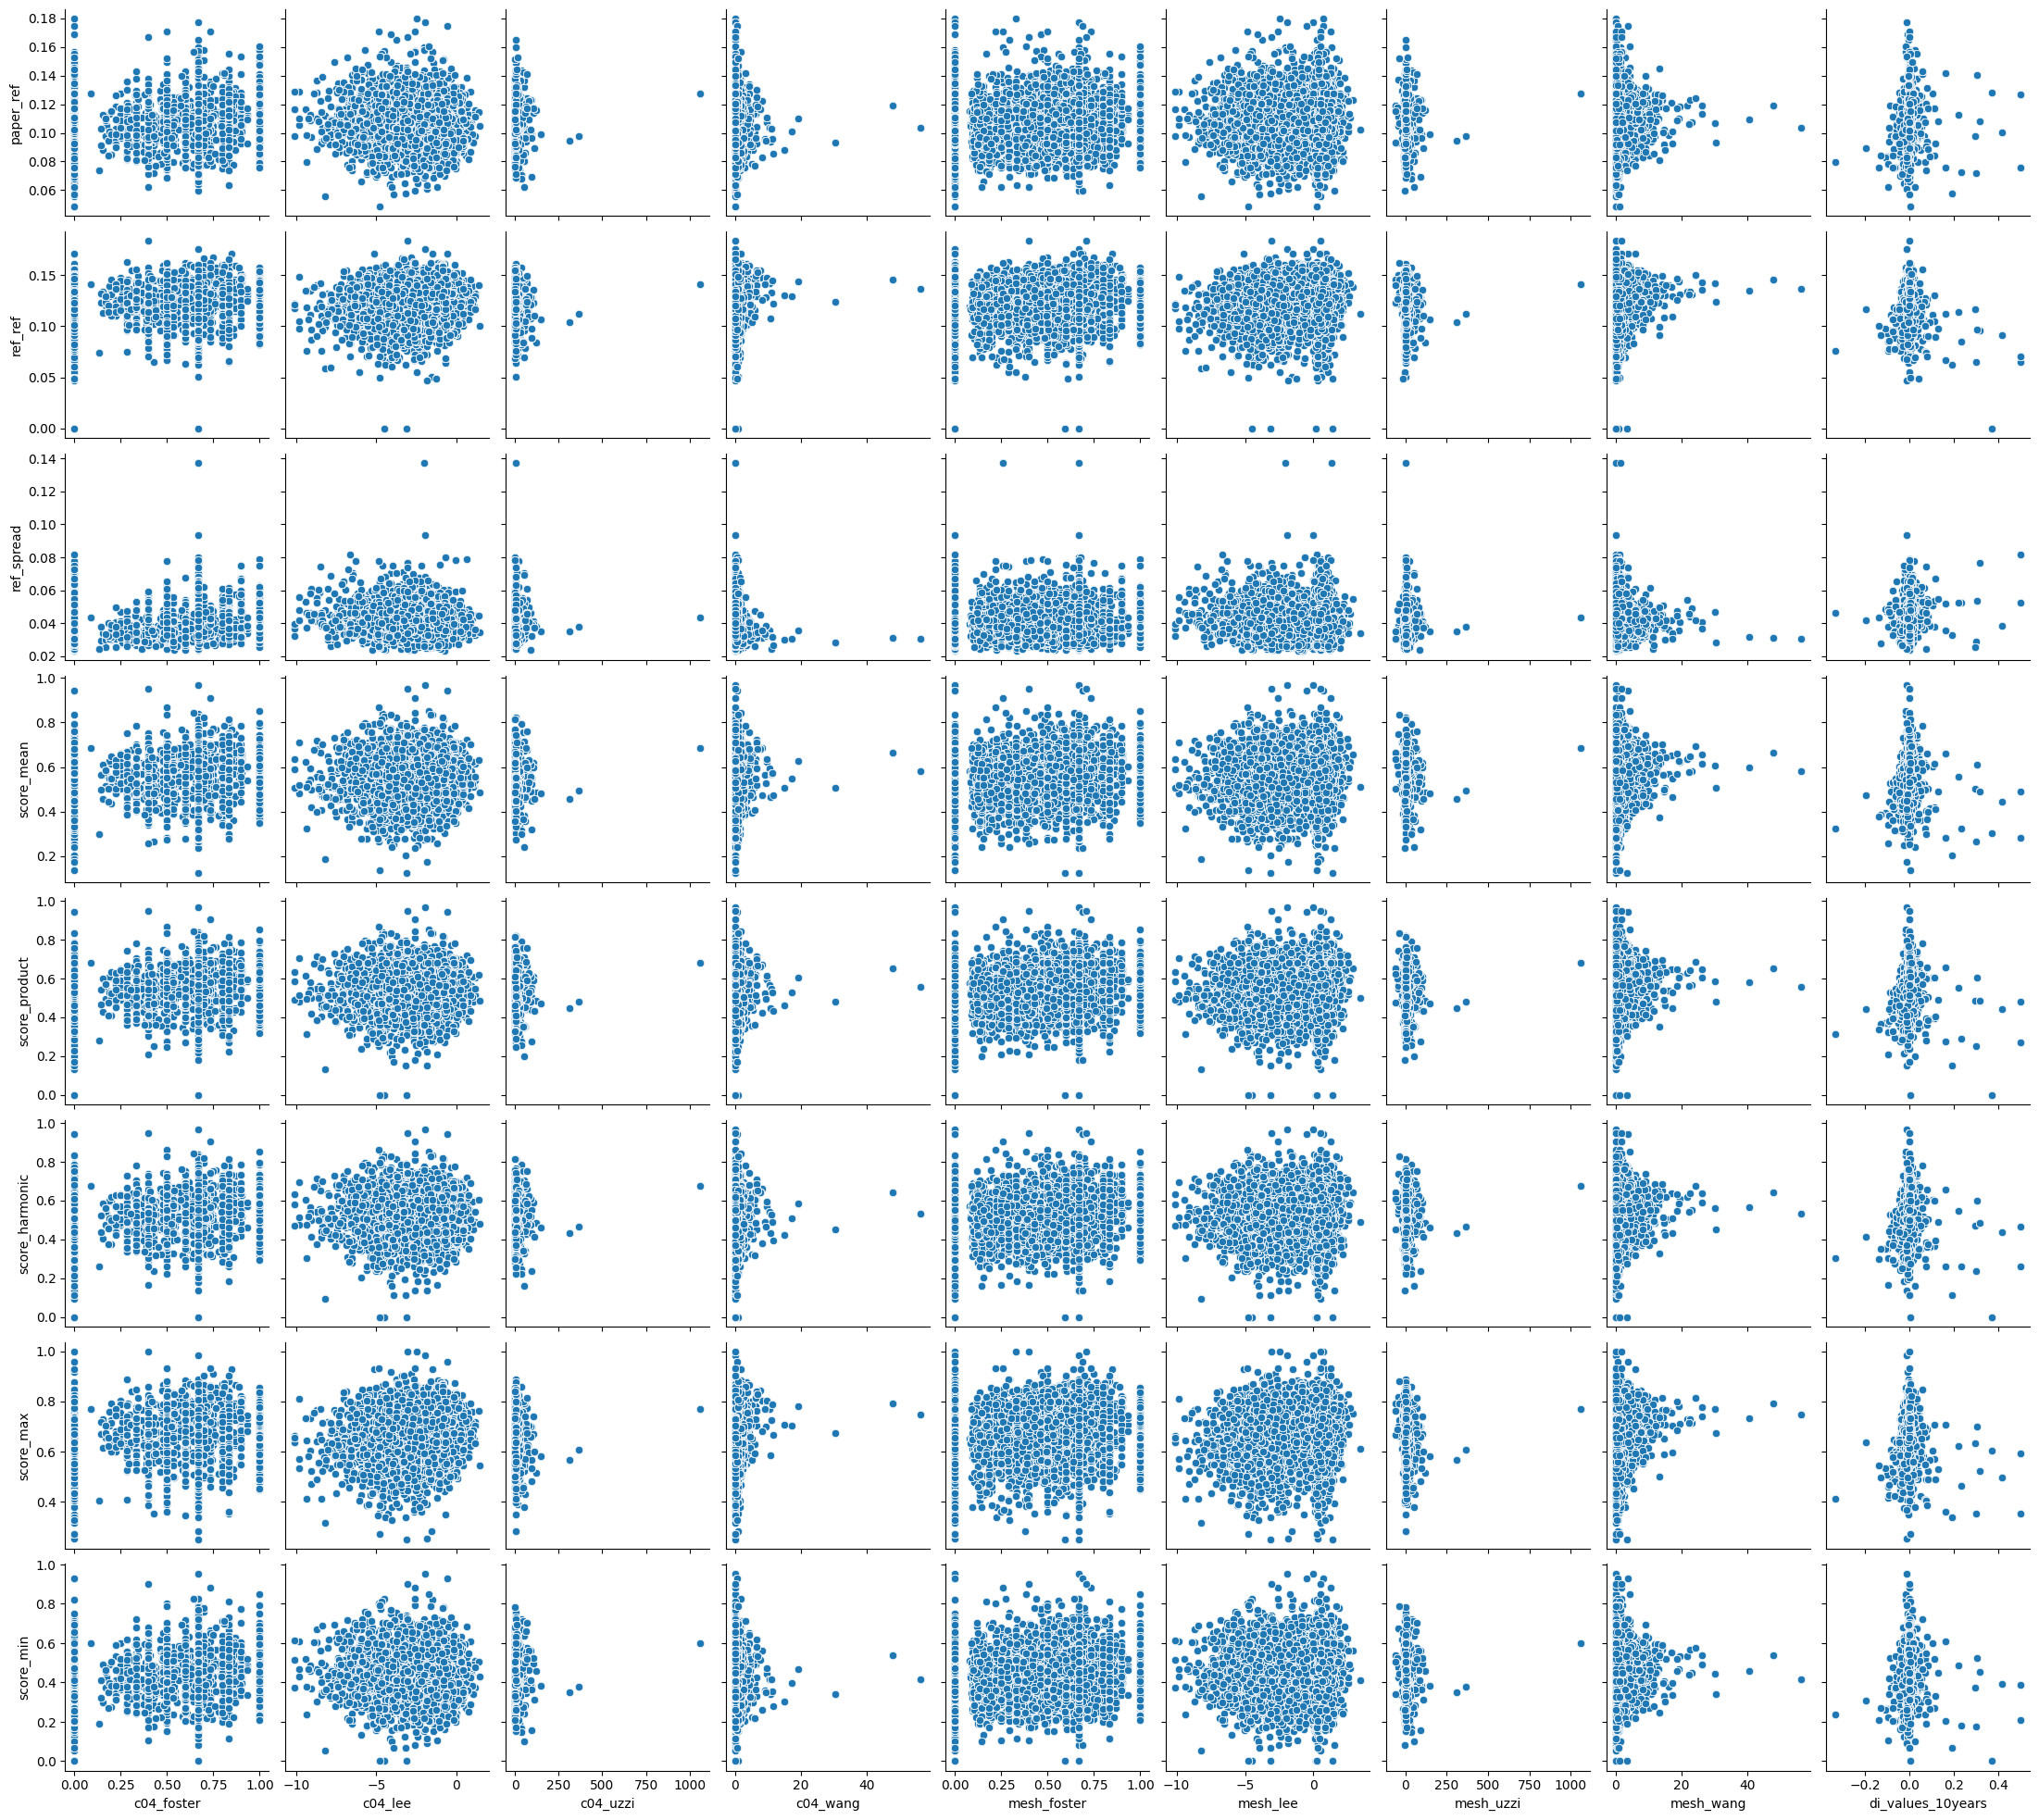

In [69]:
import seaborn as sns

sns.pairplot(y_vars=our_scores, x_vars=target_scores, data=sel)